In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import string
from datetime import datetime
import networkx as nx
from matplotlib.patches import Polygon, Ellipse
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch
from matplotlib.lines import Line2D
from matplotlib.ticker import MultipleLocator
from matplotlib.patches import Wedge
from matplotlib.patches import Circle, Rectangle
from matplotlib import transforms

In [14]:
def build_weighted_three_layer_network(df,zone_col='zone',host_col='host',virus_col='virus'):

    G = nx.Graph()

    # ---- 添加节点 ----
    for col, layer in zip([zone_col, host_col, virus_col],['zone', 'host', 'virus']):
        for n in df[col].unique():
            G.add_node(n, layer=layer)

    # ---- 计算权重 ----
    zh_weight = df.groupby([zone_col, host_col]).size()
    hv_weight = df.groupby([host_col, virus_col]).size()

    # ---- 添加加权边 ----
    for (z, h), w in zh_weight.items():
        G.add_edge(z, h, weight=w, layer='zone-host')

    for (h, v), w in hv_weight.items():
        G.add_edge(h, v, weight=w, layer='host-virus')

    return G


def draw_skewed_layer(ax, x_left, x_right, y_center, height, skew, color='lightgray', alpha=0.8, zorder=0):
    y0 = y_center - height / 2
    y1 = y_center + height / 2
    poly = Polygon(
        [(x_left + skew, y1), (x_right + skew, y1),
         (x_right - skew, y0), (x_left - skew, y0)],
        closed=True,
        facecolor=color,
        edgecolor='none',
        alpha=alpha,
        zorder=zorder
    )
    ax.add_patch(poly)


def nodes_on_skewed_layer_fast(nodes, x_left, x_right, y_center, height, skew,
                               min_dist=0.6, seed=1, max_trials=1000, layer_name=None,
                               zone_scale=0.8):
    rng = np.random.default_rng(seed)
    pos = {}

    y0 = y_center - height/2
    y1 = y_center + height/2

    # 矩形四个角
    bl = (x_left - skew, y0)  # bottom left
    br = (x_right - skew, y0) # bottom right
    tr = (x_right + skew, y1) # top right
    tl = (x_left + skew, y1)  # top left

    if layer_name == 'zone' and len(nodes) > 0:
        # ⚡ 按 zone 名称排序: 1,2,3,4
        # try:
        #     nodes = sorted(nodes, key=lambda x: int(x))  # 如果 zone 名字是数字字符串
        # except:
        #     pass  # 非数字字符串保持原顺序
        # zone_order = ['QTP', 'NW', 'SC', 'NNE']
        # order_map = {z: i for i, z in enumerate(zone_order)}

        # try:
        #     nodes = sorted(nodes, key=lambda x: order_map.get(int(x), 999))
        # except:
        #     pass

        zone_order = ['QTP', 'NW', 'SC', 'NNE']
        order_map = {z: i for i, z in enumerate(zone_order)}

        nodes = sorted(nodes, key=lambda x: order_map.get(x, 999))
        n_nodes = len(nodes)
        # zone_scale 控制左右缩进
        u_start = (1 - zone_scale)/2
        u_end = 1 - (1 - zone_scale)/2

        for i in range(n_nodes):
            u = u_start + i/(n_nodes-1)*(u_end-u_start) if n_nodes > 1 else 0.5
            # 中线插值: bottom-left + 50% height
            x = (bl[0] + u*(br[0]-bl[0]) + tl[0] + u*(tr[0]-tl[0])) / 2
            y = (bl[1] + u*(br[1]-bl[1]) + tl[1] + u*(tr[1]-tl[1])) / 2
            pos[nodes[i]] = (x, y)
        return pos

    # ---------- 其他层保持随机分布 ----------
    grid = {}
    cell_size = min_dist
    def cell_index(x, y):
        return int(x // cell_size), int(y // cell_size)

    for n in nodes:
        placed = False
        for _ in range(max_trials):
            u, v = rng.random(), rng.random()  # 随机比例
            # 仿射插值计算矩形内部坐标
            x = (1-v)*(bl[0] + u*(br[0]-bl[0])) + v*(tl[0] + u*(tr[0]-tl[0]))
            y = (1-v)*(bl[1] + u*(br[1]-bl[1])) + v*(tl[1] + u*(tr[1]-tl[1]))

            cx, cy = cell_index(x, y)
            ok = True
            for dx in (-1,0,1):
                for dy in (-1,0,1):
                    for px, py in grid.get((cx+dx, cy+dy), []):
                        if (x-px)**2 + (y-py)**2 < min_dist**2:
                            ok = False
                            break
                    if not ok: break
                if not ok: break

            if ok:
                pos[n] = (x, y)
                grid.setdefault((cx, cy), []).append((x, y))
                placed = True
                break

        if not placed:
            pos[n] = (x, y)
            grid.setdefault((cx, cy), []).append((x, y))

    return pos

def generate_county_positions_in_zone(x_center, y_center, node_size, county_count, min_dist=0.6, seed=1):
    """
    使用复杂网络的非重叠布局生成 county 坐标
    在 zone 节点的椭圆范围内
    """
    rng = np.random.default_rng(seed)
    pos = {}
    a = np.sqrt(node_size) / 100.0      # 水平半轴
    b = a * 0.6                         # 垂直半轴
    cell_size = min_dist
    grid = {}

    def cell_index(x, y):
        return int(x // cell_size), int(y // cell_size)

    for i in range(county_count):
        placed = False
        for _ in range(5000):  # 最大尝试次数
            u, v = rng.random(), rng.random()
            r = np.sqrt(u)
            theta = 2 * np.pi * v
            x = x_center + a * r * np.cos(theta)
            y = y_center + b * r * np.sin(theta)

            cx, cy = cell_index(x, y)
            ok = True
            for dx in (-1,0,1):
                for dy in (-1,0,1):
                    for px, py in grid.get((cx+dx, cy+dy), []):
                        if (x-px)**2 + (y-py)**2 < min_dist**2:
                            ok = False
                            break
                    if not ok: break
                if not ok: break

            if ok:
                pos[i] = (x, y)
                grid.setdefault((cx, cy), []).append((x, y))
                placed = True
                break

        if not placed:
            # 尝试失败直接放置
            pos[i] = (x, y)
            grid.setdefault((cx, cy), []).append((x, y))

    xs, ys = zip(*pos.values())
    return xs, ys


def plot_weighted_three_layer_network_with_county(G, ax, county_count_per_zone, x_range=(-12,12), edge_alpha=0.1, layer_cfg=None,seed=1, min_node_size=10, max_node_size=100, scale=0.2):

    if layer_cfg is None:
        layer_cfg = {
            'virus': dict(y=6, skew=2, height=3.2),
            'host': dict(y=0, skew=2, height=3.2),
            'zone': dict(y=-6, skew=2, height=3.2)
        }

    # ---------- 节点布局 ----------
    pos = {}
    for layer in ['zone','host','virus']:
        nodes = [n for n,d in G.nodes(data=True) if d['layer']==layer]
        pos.update(
            nodes_on_skewed_layer_fast(
                nodes,
                x_range[0], x_range[1],
                layer_cfg[layer]['y'],
                layer_cfg[layer]['height'],
                layer_cfg[layer]['skew'],
                seed=seed,
                layer_name=layer
            )
        )

    # ---------- 层背景 ----------
    for layer, cfg in layer_cfg.items():
        draw_skewed_layer(ax, x_range[0]-0.5, x_range[1]+0.5, cfg['y'], cfg['height']+0.6, cfg['skew'])

    # ---------- 绘制边 ----------
    weights = np.array([d['weight'] for _,_,d in G.edges(data=True)])
    widths = 0.5 + 2.5 * (weights / max(1, weights.max()))
    nx.draw_networkx_edges(G, pos, ax=ax, width=widths, edge_color='gray', alpha=edge_alpha)

    # ---------- 计算节点大小 ----------
    node_sizes = {}
    for n in G.nodes():
        wsum = sum(d['weight'] for _,_,d in G.edges(n, data=True))
        node_sizes[n] = min_node_size + (max_node_size-min_node_size)*(wsum/max(1,weights.max()))
        node_sizes[n] *= scale

    # ---------- 绘制网络节点 ---------- #
    for layer in ['zone','host','virus']:
        nodes = [n for n,d in G.nodes(data=True) if d['layer']==layer]
        for n in nodes:
            x, y = pos[n]
            if layer=='virus':
                size = node_sizes[n]*1.0
            else:
                size = node_sizes[n]
            width = np.sqrt(size) / 10        # 调整椭圆宽度
            height = np.sqrt(size) / 13       # 调整椭圆高度
            # layer_cfg 中的 skew 用作椭圆旋转角度
            angle = np.degrees(np.arctan2(layer_cfg[layer]['skew'], layer_cfg[layer]['height']))
            
            if layer == 'zone':
                color = '#E64B35'
            elif layer == 'host':
                color = '#00A087'
            else:  # virus
                color = '#3C5488'
            
            ell = Ellipse(
                (x, y),
                width=width,
                height=height,
                angle=angle,
                facecolor=color,
                edgecolor=color,
                alpha=1.0,
                zorder=5
            )
            ax.add_patch(ell)

    # ---------- zone节点内部绘制county点（不重叠） ----------
    # ---------- zone节点内部绘制county点（使用 spring 布局，椭圆限制） ----------
    for z_node in [n for n,d in G.nodes(data=True) if d['layer']=='zone']:
        x_center, y_center = pos[z_node]
        county_count = county_count_per_zone.get(z_node, 0)
        if county_count < 1:
            continue

        # 1️⃣ 构建全连网络
        H = nx.complete_graph(county_count)

        # 2️⃣ 使用 spring_layout 生成局部坐标
        local_pos = nx.spring_layout(H, seed=seed, scale=1.0)

        # 3️⃣ 转换为椭圆范围
        xs = np.array([x for x, y in local_pos.values()])
        ys = np.array([y for x, y in local_pos.values()])

        # 归一化到 [-1,1]
        xs = (xs - xs.min()) / (xs.max() - xs.min()) * 2 - 1
        ys = (ys - ys.min()) / (ys.max() - ys.min()) * 2 - 1

        # 映射到椭圆内部
        a = np.sqrt(node_sizes[z_node]) / 10.0   # zone 节点水平半轴
        b = a * 0.9                            # zone 节点垂直半轴
        shrink_factor = 0.4                       # 缩放系数，防止超出椭圆

        cfg = layer_cfg['zone']
        skew = cfg['skew']
        height = cfg['height']

        for i, (node, _) in enumerate(local_pos.items()):
            x = x_center + xs[i] * a * shrink_factor
            y = y_center + ys[i] * b * shrink_factor
            # skew 调整倾斜
            y += (x - x_center) * skew / (x_range[1] - x_range[0])
            local_pos[node] = (x, y)

        # 4️⃣ 绘制 county 节点（使用 Ellipse，更直观）
        for x, y in local_pos.values():
            ell = Ellipse(
                (x, y),
                width=0.01,
                height=0.01,
                facecolor='#4DBBD5',
                edgecolor='#4DBBD5',
                zorder=6
            )
            ax.add_patch(ell)

    # # ---------- zone 节点文字标注（从左到右） ----------
    # zone_texts = ["QTP", "NW", "SC", "NNE"]
   
    # # 取出 zone 节点并按 x 坐标排序
    # zone_nodes = [(n, pos[n]) for n, d in G.nodes(data=True) if d['layer'] == 'zone']
    # zone_nodes_sorted = sorted(zone_nodes, key=lambda x: x[1][0])  # 按 x 排序

    # for (label, (z_node, (x, y))) in zip(zone_texts, zone_nodes_sorted):
    #     ax.text(
    #         x,
    #         y - 1.5,          # 👉 文字在 zone 节点上方（可调）
    #         label,
    #         ha='center',
    #         va='bottom',
    #         fontsize=10,
    #         color='black',
    #         zorder=10,
    #         fontfamily='Arial',   # ✅ 指定字体为 Arial
    #     )
    # ---------- zone 节点文字标注 ----------
    for z_node in [n for n, d in G.nodes(data=True) if d['layer'] == 'zone']:

        x, y = pos[z_node]

        county_count = county_count_per_zone.get(z_node, 0)

        label = f"{z_node}"

        ax.text(
            x,
            y - 1.5,
            label,
            ha='center',
            va='bottom',
            fontsize=10,
            color='black',
            zorder=10,
            fontfamily='Arial'
        )

    ax.set_xlim(x_range[0]-3, x_range[1]+3)
    ax.set_ylim(-10,10)
    ax.axis('off')


def get_network_node_info_weighted(G, min_node_size=10, max_node_size=100, scale=0.2):
    """
    根据三层加权网络G，生成节点信息表：
    node, layer, weighted_degree, node_size
    """
    node_info = []

    # 最大权重，用于缩放节点大小
    weights = np.array([d['weight'] for _,_,d in G.edges(data=True)])
    max_w = max(1, weights.max())

    for n, d in G.nodes(data=True):
        layer = d.get('layer', None)

        # ⚡ 加权度数
        weighted_deg = G.degree(n, weight='weight')

        # 节点大小计算逻辑保持一致
        wsum = sum(ed['weight'] for _,_,ed in G.edges(n, data=True))
        size = min_node_size + (max_node_size - min_node_size) * (wsum / max_w)
        size *= scale

        node_info.append({
            'node': n,
            'layer': layer,
            'weighted_degree': weighted_deg,
            'node_size': size
        })

    df_nodes = pd.DataFrame(node_info)
    return df_nodes


def plot_network_main(ax):
    # 1️⃣ 读取数据
    df = pd.read_excel(r'input/host_virus-NEW-0313.xlsx')
    df = df[df['virus_new'].notna()].reset_index(drop=True)
    df = df[['zone', 'Host_species', 'virus_new', 'County']]
    df = df.rename(columns={'Host_species': 'host', 'virus_new': 'virus'})

    # 2️⃣ 拆分多病毒行
    df_new = (
        df
        .assign(virus=df['virus'].str.split(','))
        .explode('virus')
        .assign(virus=lambda x: x['virus'].str.strip())
        .reset_index(drop=True)
    )
    df_new[['host', 'virus']] = df_new[['host', 'virus']].apply(lambda x: x.str.strip())

    # 3️⃣ 统计每个分区包含的不重复County数
    county_count_per_zone = df_new.groupby('zone')['County'].nunique().to_dict()
    print(county_count_per_zone)
    # county_count_per_zone: {'Zone1': 3, 'Zone2': 5, ...}

    # 4️⃣ 构建三层网络
    G = build_weighted_three_layer_network(df_new)
    df_node_info = get_network_node_info_weighted(G)
    df_node_info.to_excel(r'output/node_info.xlsx', index=False)
    # 5️⃣ 绘图
    plot_weighted_three_layer_network_with_county(G, ax, county_count_per_zone)
    layer_counts = (
    pd.DataFrame([d for _, d in G.nodes(data=True)])['layer']
    .value_counts())
    print(layer_counts)

def plot_legend(ax):
    colors = ['#3C5488', '#00A087','#E64B35', '#4DBBD5']
    labels = ['Virus', 'Host', 'Biogeographical region', 'County']

    # 用 Line2D 生成圆形图例
    handles = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor=c, markersize=10, label=l)
        for c, l in zip(colors, labels)
    ]

    ax.legend(handles=handles, loc='center', frameon=False, ncol=4, prop={'family': 'Arial'} )
    ax.set_xticks([])
    ax.set_yticks([])
    ax.axis('off')

{'NNE': 47, 'NW': 16, 'QTP': 4, 'SC': 103}
layer
virus    2029
host       97
zone        4
Name: count, dtype: int64


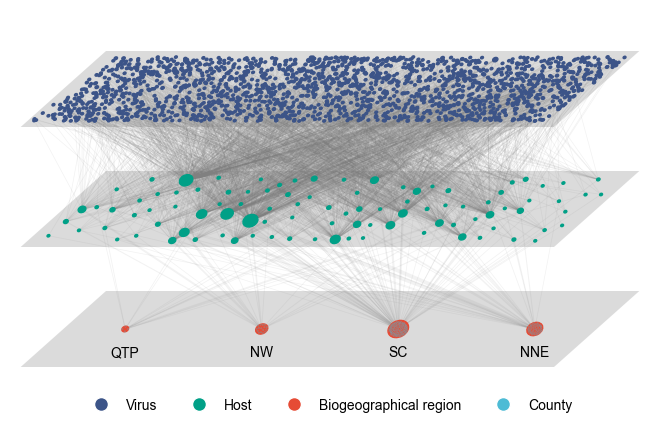

In [15]:
fig = plt.figure(figsize=(8, 8))

letters = list(string.ascii_lowercase)

# ============================================================
#                       Zone-host-virus networks
# ============================================================
scale=1.0
ax1 = fig.add_axes([0, 0.5, 0.8*scale, 0.5*scale])
plot_network_main(ax1)
ax1_legend = fig.add_axes([0, 0.48, 0.8*scale, 0.05*scale])
plot_legend(ax1_legend)
# fig.text(0.01, 1.0, letters[0], ha='center', va='center', fontsize=10, weight='bold')

date_str = datetime.now().strftime("%Y%m%d")  # 例如 20260107
plt.subplots_adjust(left=0, right=1, top=1, bottom=0)
plt.savefig(f'figure/Network_{date_str}.pdf', bbox_inches='tight', pad_inches=0.05)
plt.savefig(f'figure/Network_{date_str}.tif', bbox_inches='tight', pad_inches=0.05, dpi=500) 
plt.show()

In [9]:
def plot_sunburst(ax, df, modularity_value=0.55, outer_markers=None):
    import numpy as np
    import pandas as pd
    import matplotlib.transforms as transforms
    from matplotlib.patches import Circle, Rectangle

    # ===============================
    # 1️⃣ 指定模块展示顺序
    # ===============================
    module_order = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
    n_modules = len(module_order)

    # ===============================
    # 2️⃣ 统计 virus / host（按顺序重排）
    # ===============================
    virus_by_module = df.groupby("module")["virus"].sum().reindex(module_order, fill_value=0)
    host_by_module = df.groupby("module")["host"].sum().reindex(module_order, fill_value=0)
    virus_total_by_module = df.groupby("module")["virus_total"].first().reindex(module_order)
    host_total_by_module = df.groupby("module")["host_total"].first().reindex(module_order)

    # ===============================
    # 3️⃣ zone颜色与取值
    # ===============================
    zone_colors = {1: "#E64B35", 2: "#00A087", 3: "#3C5488", 4: "#4DBBD5"}
    gray_color = "#D3D3D3"

    zone_mask = {mod: not df[df["module"] == mod]["zone"].dropna().empty for mod in module_order}

    module_colors = []
    zone_value = {}
    for mod in module_order:
        if zone_mask[mod]:
            z = int(df[df["module"] == mod]["zone"].dropna().iloc[0])
            module_colors.append(zone_colors.get(z, gray_color))
            zone_value[mod] = z
        else:
            module_colors.append(gray_color)
            zone_value[mod] = None

    sizes = np.ones(n_modules)

    # ===============================
    # 4️⃣ 绘制四层旭日图
    # ===============================
    wedges1, _ = ax.pie(sizes, radius=1.25, startangle=90, counterclock=False,
                        colors=module_colors, wedgeprops=dict(width=0.25, edgecolor="white"))
    wedges2, _ = ax.pie(sizes, radius=1.0, startangle=90, counterclock=False,
                        colors=module_colors, wedgeprops=dict(width=0.25, edgecolor="white", alpha=0.85))
    wedges3, _ = ax.pie(sizes, radius=0.75, startangle=90, counterclock=False,
                        colors=module_colors, wedgeprops=dict(width=0.25, edgecolor="white", alpha=0.7))
    wedges4, _ = ax.pie(sizes, radius=0.5, startangle=90, counterclock=False,
                        colors=module_colors, wedgeprops=dict(width=0.25, edgecolor="white", alpha=1.0))

    zone_label_map = {1: 'QTP', 2: 'NW', 3: 'SC', 4: 'NNE'}

    # ===============================
    # 5️⃣ 添加数字及分区标注（增加换行，旋转角度一致）
    # ===============================
    for i, (mod, w) in enumerate(zip(module_order, wedges1)):
        v = virus_by_module[mod]
        h = host_by_module[mod]
        vt = virus_total_by_module[mod]
        ht = host_total_by_module[mod]
        z = zone_value[mod]

        # 统一扇形中心角
        angle_mid = (w.theta1 + w.theta2) / 2
        theta_mid = np.deg2rad(angle_mid)

        # 千分位显示 + 换行
        virus_label = f"{v:,}\n({int(vt):,})" if pd.notna(vt) else f"{v:,}"
        host_label = f"{h:,}\n({int(ht):,})" if pd.notna(ht) else f"{h:,}"

        # -------- 外圈：virus --------
        ax.text(1.125 * np.cos(theta_mid), 1.125 * np.sin(theta_mid),
                virus_label, ha="center", va="center",
                fontsize=9, fontfamily="Arial",
                rotation=angle_mid - 90, rotation_mode="anchor")

        # -------- 第二圈：host --------
        ax.text(0.875 * np.cos(theta_mid), 0.875 * np.sin(theta_mid),
                host_label, ha="center", va="center",
                fontsize=9, fontfamily="Arial",
                rotation=angle_mid - 90, rotation_mode="anchor")

        # -------- 第三圈：zone --------
        ax.text(0.625 * np.cos(theta_mid), 0.625 * np.sin(theta_mid),
                zone_label_map.get(z, "-"), ha="center", va="center",
                fontsize=9, fontfamily="Arial",
                rotation=angle_mid - 90, rotation_mode="anchor")

        # -------- 第四圈：module 编号 --------
        ax.text(0.375 * np.cos(theta_mid), 0.375 * np.sin(theta_mid),
                str(i + 1), ha="center", va="center",
                fontsize=9, fontfamily="Arial",
                rotation=angle_mid - 90, rotation_mode="anchor")

    # ===============================
    # 6️⃣ 外侧符号
    # ===============================
    for i, w in enumerate(wedges1):
        mod = module_order[i]
        z = zone_value[mod]
        h = host_by_module[mod]
        v = virus_by_module[mod]

        if z is None:
            angle_mid = (w.theta1 + w.theta2) / 2
            theta_mid = np.deg2rad(angle_mid)
            r_base = 1.35
            delta_theta = np.deg2rad(5)

            if (h == 2 and v == 90) or (h==1 and v==21):
                x = r_base * np.cos(theta_mid)
                y = r_base * np.sin(theta_mid)

                size = 0.06
                rect = Rectangle(
                    (x - size/2, y - size/2),   # 左下角
                    size,
                    size,
                    facecolor='#8491B4',
                    edgecolor='#8491B4',
                    zorder=5
                )
                ax.add_patch(rect)

                # x = r_base * np.cos(theta_mid - delta_theta)
                # y = r_base * np.sin(theta_mid - delta_theta)
                # rect = Rectangle((-0.03, -0.03), 0.06, 0.06,facecolor='#8491B4', edgecolor='#8491B4', zorder=5)
                # t = transforms.Affine2D().rotate(theta_mid).translate(x, y) + ax.transData
                # rect.set_transform(t)
                # ax.add_patch(rect)
            else:
                x = r_base * np.cos(theta_mid)
                y = r_base * np.sin(theta_mid)
                ax.add_patch(Circle((x, y), 0.03, facecolor='#F39B7F', edgecolor='#F39B7F', zorder=5))

    # ===============================
    # 7️⃣ 中心模块度
    # ===============================
    ax.text(0, 0, f"{modularity_value:.2f}",
            ha="center", va="center",
            fontsize=12, fontweight="bold", fontfamily="Arial")

    ax.set(aspect="equal")
    ax.set_xlim(-1.5, 1.5)
    ax.set_ylim(-1.5, 1.5)
    ax.axis("off")


def plot_sunbrustlegend(ax):
    from matplotlib.lines import Line2D
    colors = ['#F39B7F', '#8491B4']
    labels = ['Localized host-specific virus', 'Virus with broadly distributed hosts']
    markers = ['o', 's']

    handles = [Line2D([0], [0], marker=m, color='w', markerfacecolor=c, markersize=10, label=l)
               for c, l, m in zip(colors, labels, markers)]
    ax.legend(handles=handles, loc='center', frameon=False, ncol=1, prop={'family': 'Arial'})
    ax.axis('off')


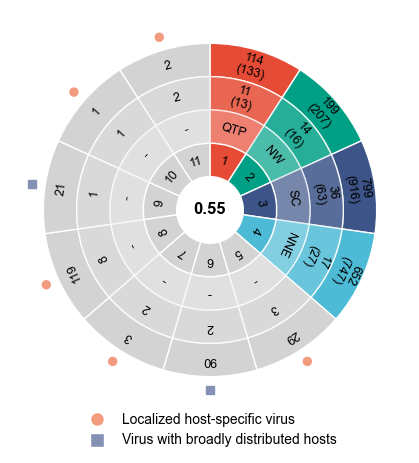

In [10]:
fig = plt.figure(figsize=(8, 8))

letters = list(string.ascii_lowercase)

ax6 = fig.add_axes([0, 0, 0.5, 0.5])
plot_sunburst(ax=ax6, df=pd.read_excel(r'output/3_modularity/module_zone_host_virus.xlsx'))
# fig.text(0.55, 0.15, letters[5], ha='center', va='center', fontsize=10, weight='bold')
ax7 = fig.add_axes([0, -0.05, 0.5, 0.05])
plot_sunbrustlegend(ax7)

date_str = datetime.now().strftime("%Y%m%d")  # 例如 20260107
plt.subplots_adjust(left=0, right=1, top=1, bottom=0)
plt.savefig(f'figure/Modularity_{date_str}.pdf', bbox_inches='tight', pad_inches=0.05)
plt.savefig(f'figure/Modularity_{date_str}.tif', bbox_inches='tight', pad_inches=0.05, dpi=500)
plt.show()

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


def get_four_zone_positions(zones=None):
    """返回四个节点固定位置"""
    pos_template = [(0, 1), (1, 1), (1, 0), (0, 0)]  # 上、右、下、左

    if zones is None:
        zones = ['NW', 'NNE', 'SC', 'QTP']

    return dict(zip(zones, pos_template))


def draw_zones(ax, pos, node_size=800, color='#E64B35'):
    """绘制四个分区节点"""

    ZONE_TEXT = {
        'SC': "South China",
        'NNE': "North-Northeast",
        'QTP': "Qinghai-Tibet Plateau",
        'NW': "Northwestern"
    }

    ZONE_ABBR = {
        'SC': "SC",
        'NNE': "NNE",
        'QTP': "QTP",
        'NW': "NW"
    }

    for z, (x, y) in pos.items():

        ax.scatter(x, y, s=node_size, c=color, zorder=3)

        # 圈内缩写
        ax.text(
            x, y, ZONE_ABBR[z],
            ha='center', va='center',
            fontsize=10,
            color='black',
            zorder=4,
            fontfamily='Arial'
        )

        # 标签位置
        if x <= 0.1:      # 左
            dx, ha = -0.3, 'right'
        elif x >= 0.9:    # 右
            dx, ha = 0.3, 'left'
        else:
            dx, ha = 0.3, 'left'

        ax.text(
            x + dx, y,
            ZONE_TEXT[z],
            ha=ha, va='center',
            fontsize=10,
            color='black',
            zorder=4,
            fontfamily='Arial'
        )


def draw_straight_flow(ax, p1, p2, width=2):
    """绘制直线"""
    ax.plot(
        [p1[0], p2[0]],
        [p1[1], p2[1]],
        linewidth=width,
        zorder=2,
        linestyle='-',
        color='#3C5488'
    )


def draw_curve_flow(ax, p_start, p_mid, p_end, width=2, offset=0.15):
    """
    绘制曲线，通过中间节点
    """

    vec = np.array(p_end) - np.array(p_start)

    vec_perp = np.array([-vec[1], vec[0]])
    vec_perp = vec_perp / np.linalg.norm(vec_perp) * offset

    p_mid_offset = np.array(p_mid) + vec_perp

    P0, P1, P2 = np.array(p_start), p_mid_offset, np.array(p_end)

    t = np.linspace(0, 1, 100)

    curve = (
        np.outer((1 - t) ** 2, P0) +
        np.outer(2 * (1 - t) * t, P1) +
        np.outer(t ** 2, P2)
    )

    ax.plot(
        curve[:, 0],
        curve[:, 1],
        linewidth=width,
        zorder=1,
        linestyle='-',
        color='#00A087'
    )


def plot_zone_flow_from_path(
        filepath,
        ax=None,
        flow_col='flow',
        path_col='path',
        sep='→',
        min_width=1,
        max_width=8,
        scale_width=0.8):
    """绘制 zone-zone flow"""

    # 读取数据
    if filepath.endswith('.xlsx'):
        df = pd.read_excel(filepath)
    else:
        df = pd.read_csv(filepath)

    # 固定分区顺序
    zones = ['NW', 'NNE', 'SC', 'QTP']

    pos = get_four_zone_positions(zones)

    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 6))

    draw_zones(ax, pos)

    flows = df[flow_col].values

    widths = (
        min_width +
        (flows / flows.max()) *
        (max_width - min_width)
    ) * scale_width

    for (_, row), width in zip(df.iterrows(), widths):

        path = [z.strip() for z in str(row[path_col]).split(sep)]

        if len(path) == 2:

            draw_straight_flow(
                ax,
                pos[path[0]],
                pos[path[1]],
                width
            )

        elif len(path) == 3:

            draw_curve_flow(
                ax,
                pos[path[0]],
                pos[path[1]],
                pos[path[2]],
                width
            )

        else:
            print(f"Warning: path 长度不是 2 或 3，跳过 {path}")

    ax.set_aspect('equal')

    ax.set_xlim(-0.5, 1.5)
    ax.set_ylim(-0.5, 1.5)

    ax.axis('off')

    return ax


def plot_flow_legend(ax):
    """绘制图例"""

    colors = ['#3C5488', '#00A087']

    labels = [
        'Directly connected',
        'Indirectly connected'
    ]

    handles = [
        Line2D(
            [0, 1],
            [0, 0],
            color=c,
            linewidth=3,
            label=l
        )
        for c, l in zip(colors, labels)
    ]

    ax.legend(
        handles=handles,
        loc='center',
        frameon=False,
        ncol=1,
        fontsize=10,
        prop={'family': 'Arial'}
    )

    ax.set_xticks([])
    ax.set_yticks([])
    ax.axis('off')

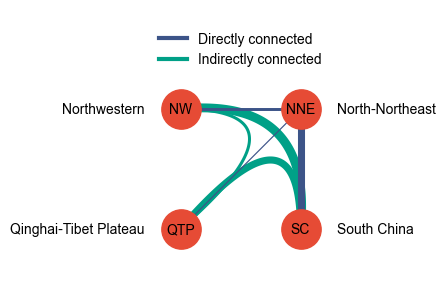

In [3]:
fig = plt.figure(figsize=(8, 8))

# # ============================================================
# #                      Zone-Zone flow
# # ============================================================
ax2 = fig.add_axes([0.8, 0.5, 0.3, 0.3])
plot_zone_flow_from_path('output/1_flow_analysis/least_resistance_paths.xlsx', ax=ax2)
ax3 = fig.add_axes([0.8, 0.75, 0.3, 0.1])
plot_flow_legend(ax3)

date_str = datetime.now().strftime("%Y%m%d")  # 例如 20260107
plt.subplots_adjust(left=0, right=1, top=1, bottom=0)
plt.savefig(f'figure/Flow_{date_str}.tiff', bbox_inches='tight', pad_inches=0.05)
plt.show()

In [4]:
from matplotlib.ticker import MultipleLocator

def plot_top10_bar(
    filepath, 
    target_col, 
    variable_col, 
    ylabel,
    ax=None,
    ymax=None,
    yint=None,
    top_n=10,
    bar_color='#3C5488',
):
    # 读取文件
    df = pd.read_excel(filepath) if filepath.endswith('.xlsx') else pd.read_csv(filepath)

    # 筛选前 top_n
    df_sorted = df.sort_values(variable_col, ascending=False).head(top_n)

    # 绘制条形图
    bars = ax.bar(
        range(len(df_sorted[target_col])),
        df_sorted[variable_col],
        color=bar_color,
        width=0.8
    )

    # ===============================
    # ✅ 关键修改：x 轴显示名称
    # ===============================
    labels = [name.replace('_', ' ') for name in df_sorted[target_col]]

    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(
        labels,
        rotation=60,
        fontsize=10,
        ha='right',
        fontfamily='Arial',
        fontstyle='italic' if target_col.lower() == 'host' else 'normal'
    )

    # y 轴设置
    ax.set_ylabel(ylabel, fontsize=10,fontfamily='Arial')
    ax.set_ylim(0, ymax if ymax else df_sorted[variable_col].max() * 1.15)

    # 主刻度
    ax.xaxis.set_major_locator(MultipleLocator(1))
    ax.yaxis.set_major_locator(MultipleLocator(yint))

    # 美化
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)


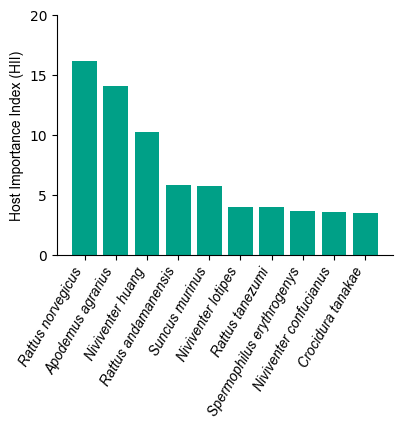

In [5]:
fig = plt.figure(figsize=(8, 8))

# # ============================================================
# #                      Key host
# # ============================================================
ax3 = fig.add_axes([0.08, 0.2, 0.42, 0.3])
plot_top10_bar(filepath='output/2_multilayer_centrality/host_centrality_weighted.xlsx', 
    target_col='host', 
    variable_col='HII', 
    ylabel='Host Importance Index (HII)',
    ax=ax3,
    ymax=20,
    yint=5,
    top_n=10,
    bar_color='#00A087'
)

date_str = datetime.now().strftime("%Y%m%d")  # 例如 20260107
plt.subplots_adjust(left=0, right=1, top=1, bottom=0)
plt.savefig(f'figure/Host_ranking_{date_str}.tiff', bbox_inches='tight', pad_inches=0.05)
plt.show()

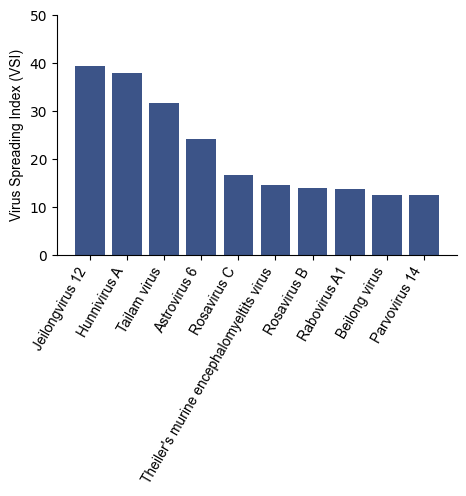

In [6]:
fig = plt.figure(figsize=(8, 8))

# # ============================================================
# #                      Key virus
# # ============================================================
ax4 = fig.add_axes([0.6, 0.2, 0.5, 0.3])
plot_top10_bar(filepath='output/2_multilayer_centrality/virus_centrality_weighted.xlsx', 
    target_col='virus', 
    variable_col='PSI', 
    ylabel='Virus Spreading Index (VSI)',
    ax=ax4,
    ymax=50,
    yint=10,
    top_n=10,
    bar_color='#3C5488'
)

date_str = datetime.now().strftime("%Y%m%d")  # 例如 20260107
plt.subplots_adjust(left=0, right=1, top=1, bottom=0)
plt.savefig(f'figure/Virus_ranking_{date_str}.tiff', bbox_inches='tight', pad_inches=0.05)
plt.show()

In [7]:
def plot_remove_node(ax):
    df_host=pd.read_excel(f'output/4_remove_node/remove_host_by_HII.xlsx')
    ax.plot(
        df_host["removed_fraction"],
        df_host["giant_component_fraction"],
        linestyle='-',
        linewidth=2,
        label='Host',
        color='#00A087'
    )

    ax.scatter(
        df_host["removed_fraction"][19], 
        df_host["giant_component_fraction"][19],
        s=10,
        color='black',
        zorder=5
    )

    ax.axvline(
        x=df_host["removed_fraction"][19],
        linestyle='--',
        color='lightgrey',
        lw=1,
        alpha=0.8,
        zorder=1
    )

    print(df_host["removed_fraction"][19])

    df_virus=pd.read_excel(f'output/4_remove_node/remove_virus_by_PSI.xlsx')
    ax.plot(
        df_virus["removed_fraction"],
        df_virus["giant_component_fraction"],
        linestyle='-',
        linewidth=2,
        label='Virus',
        color='#3C5488'
    )

    df_zone=pd.read_excel(f'output/4_remove_node/remove_zone_by_strength.xlsx')
    ax.plot(
        df_zone["removed_fraction"],
        df_zone["giant_component_fraction"],
        linestyle='-',
        linewidth=2,
        label='Region',
        color='#E64B35'
    )

    ax.set_xlabel("Fraction of nodes removed", fontsize=10, fontfamily='Arial')
    ax.set_ylabel("Relative size of giant component", fontsize=10, fontfamily='Arial')
    ax.set_ylim(-0.05, 1.05)
    ax.legend(frameon=False, prop={'family': 'Arial'})

0.2061855670103093


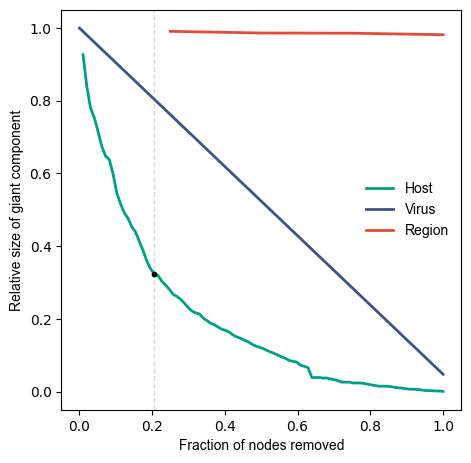

In [8]:
fig = plt.figure(figsize=(8, 8))

# # ============================================================
# #                      Remove node
# # ============================================================
ax5 = fig.add_axes([0, 0, 0.5, 0.5])
plot_remove_node(ax5)

date_str = datetime.now().strftime("%Y%m%d")  # 例如 20260107
plt.subplots_adjust(left=0, right=1, top=1, bottom=0)
plt.savefig(f'figure/Remove_node_{date_str}.tiff', bbox_inches='tight', pad_inches=0.05)
plt.show()

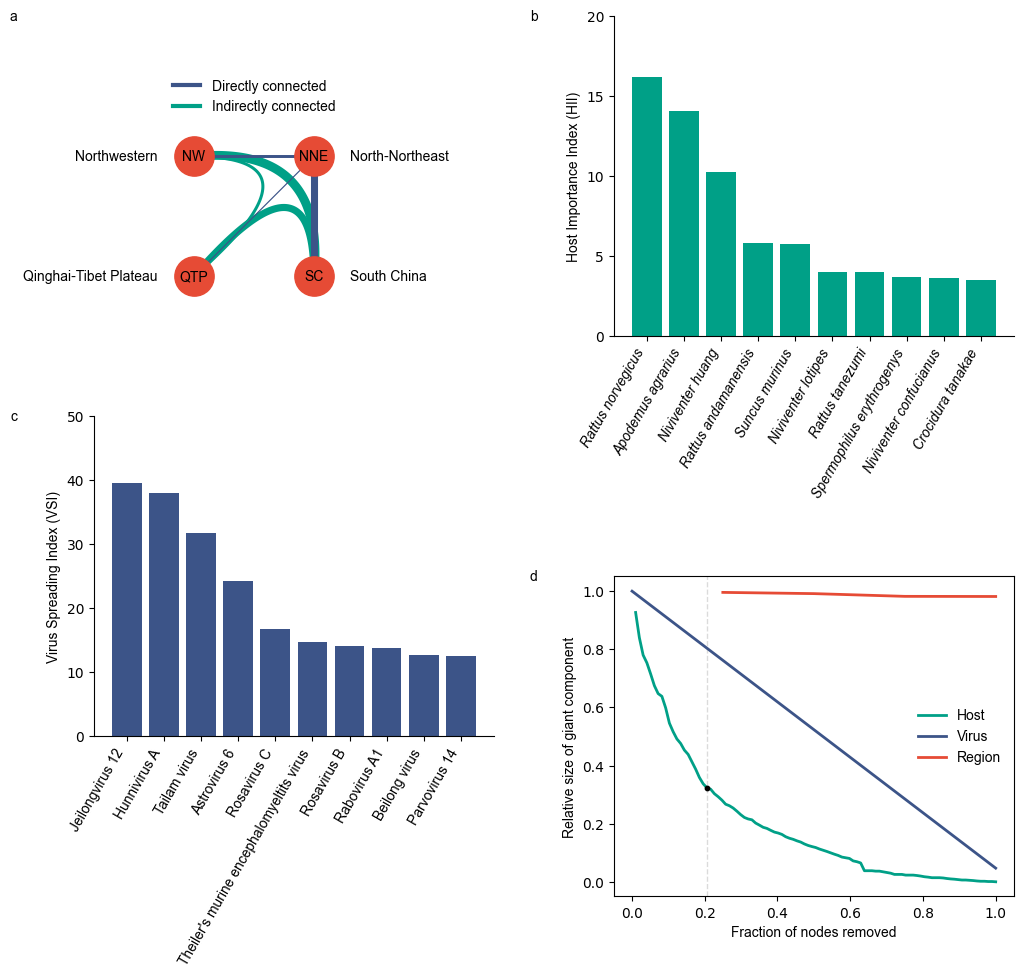

In [25]:
fig = plt.figure(figsize=(8, 8))

# # ============================================================
# #                      Zone-Zone flow
# # ============================================================
ax2 = fig.add_axes([0.0, 0.5, 0.3, 0.3])
plot_zone_flow_from_path('output/1_flow_analysis/least_resistance_paths.xlsx', ax=ax2)
ax3 = fig.add_axes([0.0, 0.75, 0.3, 0.1])
plot_flow_legend(ax3)

# # ============================================================
# #                      Key host
# # ============================================================
ax3 = fig.add_axes([0.6, 0.5, 0.5, 0.4])
plot_top10_bar(filepath='output/2_multilayer_centrality/host_centrality_weighted.xlsx', 
    target_col='host', 
    variable_col='HII', 
    ylabel='Host Importance Index (HII)',
    ax=ax3,
    ymax=20,
    yint=5,
    top_n=10,
    bar_color='#00A087'
)

# # ============================================================
# #                      Key virus
# # ============================================================
ax4 = fig.add_axes([-0.05, 0.0, 0.5, 0.4])
plot_top10_bar(filepath='output/2_multilayer_centrality/virus_centrality_weighted.xlsx', 
    target_col='virus', 
    variable_col='PSI', 
    ylabel='Virus Spreading Index (VSI)',
    ax=ax4,
    ymax=50,
    yint=10,
    top_n=10,
    bar_color='#3C5488'
)

# # ============================================================
# #                      Remove node
# # ============================================================
ax5 = fig.add_axes([0.6, -0.2, 0.5, 0.4])
plot_remove_node(ax5)


import string
letters = list(string.ascii_lowercase)
fig.text(-0.15, 0.9, letters[0], ha='center', va='center', fontsize=10, fontfamily='Arial')
fig.text(0.5, 0.9, letters[1], ha='center', va='center', fontsize=10, fontfamily='Arial')
fig.text(-0.15, 0.4, letters[2], ha='center', va='center', fontsize=10, fontfamily='Arial')
fig.text(0.5, 0.2, letters[3], ha='center', va='center', fontsize=10, fontfamily='Arial')

date_str = datetime.now().strftime("%Y%m%d")  # 例如 20260107
plt.subplots_adjust(left=0, right=1, top=1, bottom=0)
plt.savefig(f'figure/Flow_{date_str}.tiff', bbox_inches='tight', pad_inches=0.05)
plt.show()